In [6]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import datetime
import sys

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import pandas as pd
import QuantLib as ql

plt.style.use("ggplot")
pylab.rcParams.update(
    {
        "legend.fontsize": "x-large",
        "figure.figsize": (18, 8),
        "axes.labelsize": "x-large",
        "axes.titlesize": "x-large",
        "xtick.labelsize": "large",
        "ytick.labelsize": "large",
    }
)

sys.path.append("../../")

from BT.data_handler import TimeGrid
from BT.misc import (
    _last_business_day_of_month,
    _month_iter,
    _n_business_days_before,
    _nth_business_day_of_month,
    ql_cal_date_range,
)
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from Query.Base.query_resolution import resolve_query
from Query.FixedRateBonds.carry_roll import load_us_treasury_gc_fixing_pct
from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue
from BT.query_tearsheet import QueryBacktestTearSheet

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
CAL = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
risk_bpv = -100_000
unwind_fee_bps = 1.0 

start = datetime.date(2015, 1, 1)
end = datetime.date(2026, 8, 26)

days_pre_month_end = 2
days_after_month_end = 1

cycles = []
for y, m in _month_iter(start, end):
    eom_bd = _last_business_day_of_month(CAL, y, m)
    entry = _n_business_days_before(CAL, eom_bd, days_pre_month_end)
    ny, nm = (y + 1, 1) if m == 12 else (y, m + 1)
    exit_ = _nth_business_day_of_month(CAL, ny, nm, days_after_month_end)

    if entry < start or exit_ > end:
        continue

    cycles.append((entry, exit_, f"me-trade-{y:04d}{m:02d}"))

tg = TimeGrid(
    ql_cal_date_range(
        ql_cal=CAL,
        start=min(entry for entry, _, _ in cycles),
        end=max(exit_ for _, exit_, _ in cycles),
    )
)

gc_fixing_pct = pd.Series(
    {
        d: load_us_treasury_gc_fixing_pct(d)
        for d in sorted({ts.date() for ts in tg})
    },
    dtype=float,
).sort_index()

if gc_fixing_pct.isna().any():
    missing = gc_fixing_pct[gc_fixing_pct.isna()].index.tolist()
    raise ValueError(f"Missing GC fixing data for backtest dates: {missing[:10]}")

financing_config = {
    "mode": "gc_plus_specialness",
    "gc_rate": gc_fixing_pct / 100.0,
    "leg_specialness_bps": {"outright": 10.0},
    "day_count": "ACT/360",
    "haircut": 0.0,
}

frb_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")
trade_query = FixedRateBondQuery(
    cusip="oo10/CT10",
    # cusip="CT10",
    value=FixedRateBondValue.NPV,
    structure_kwargs={"bpv": risk_bpv},
    meta={"financing": financing_config},
)

len(cycles), cycles[:3]

(139,
 [(datetime.date(2015, 1, 28), datetime.date(2015, 2, 2), 'me-trade-201501'),
  (datetime.date(2015, 2, 25), datetime.date(2015, 3, 2), 'me-trade-201502'),
  (datetime.date(2015, 3, 27), datetime.date(2015, 4, 1), 'me-trade-201503')])

In [14]:
triggers = []
for entry_date, exit_date, tag in cycles:
    tagged_query = FixedRateBondQuery(
        cusip=trade_query.cusip,
        value=trade_query.value,
        structure_kwargs=dict(trade_query.structure_kwargs),
        meta=dict(trade_query.meta),
        tags=(tag,),
    )
    triggers.extend(
        [
            DateTrigger(DateTriggerRequirements(dates=[entry_date]), actions=[AddQueryAction(query=tagged_query)]),
            DateTrigger(
                DateTriggerRequirements(dates=[exit_date]),
                actions=[UnwindPositionsAction(match_tag=tag, fee=unwind_fee_bps * risk_bpv)],
            ),
        ]
    )

strategy = QueryStrategy(name=f"Month-End {trade_query.col_name()}", triggers=triggers)
bt = QueryDrivenBacktest(time_grid=tg, mdp=frb_mdp, strategy=strategy)
bt.run()


BACKTESTING...: 100%|██████████| 2880/2880 [00:08<00:00, 322.41step/s]


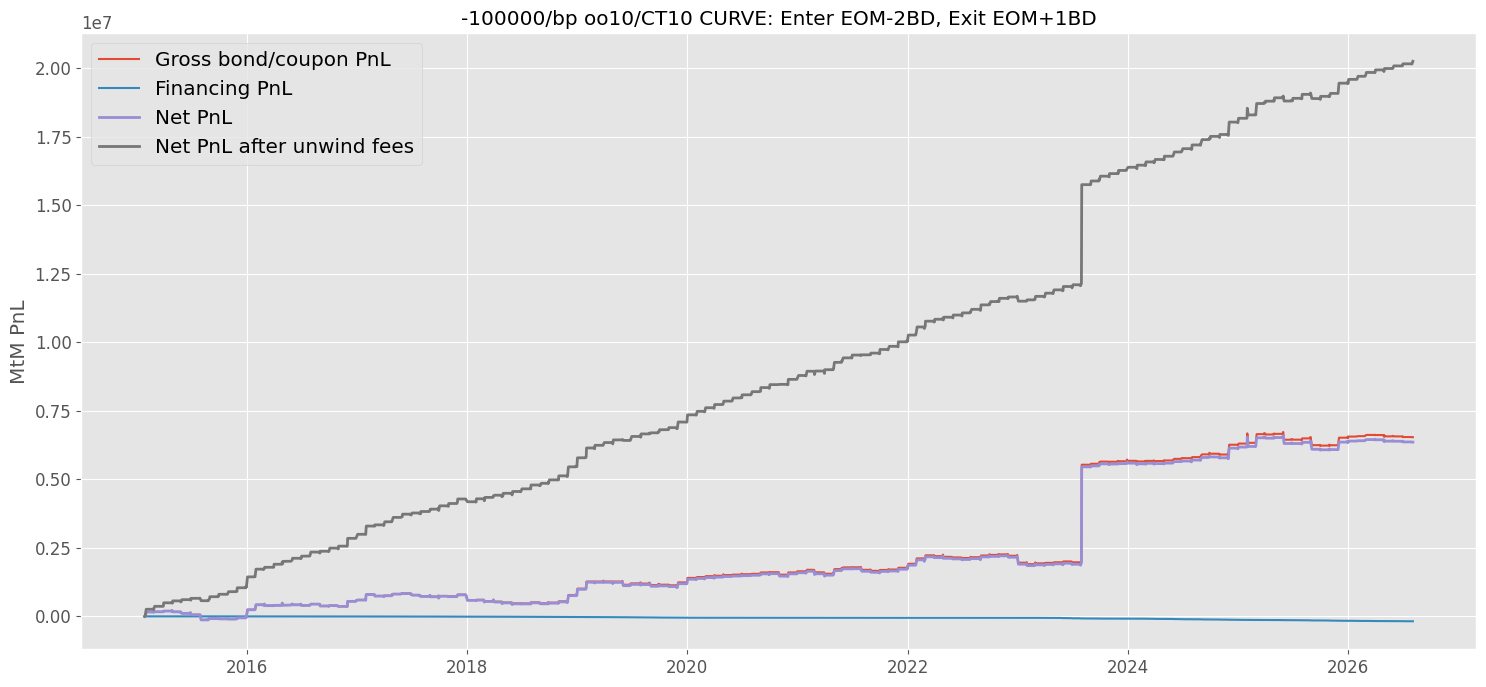

In [15]:
# mtm = pd.Series(bt.mtm_history).sort_index()
# print("Final MTM:", float(mtm.iloc[-1]))

# plt.figure()
# plt.plot(mtm.index, mtm.values, label="MtM PnL")
# plt.legend()
# plt.title(f"{risk_bpv}/bp {trade_query.col_name()[:-4]}: Enter EOM-{days_pre_month_end}BD, Exit EOM+{days_after_month_end}BD")
# plt.show()

time_index = pd.Index(list(tg), name="date")
component_histories = getattr(bt, "frb_component_histories", {})

gross_bond = pd.Series(component_histories.get("bond_total", {}), dtype=float).sort_index()
financing = pd.Series(component_histories.get("financing_total", {}), dtype=float).sort_index()
net = pd.Series(component_histories.get("net_total", {}), dtype=float).sort_index()

gross_bond = gross_bond.reindex(time_index).ffill().fillna(0.0)
financing = financing.reindex(time_index).ffill().fillna(0.0)
net = net.reindex(time_index).ffill().fillna(0.0)
closed = pd.DataFrame(bt.portfolio.closed_positions_log)

if closed.empty:
    unwind_fees = pd.Series(0.0, index=time_index)
else:
    unwind_fees = (
        closed.assign(closed_at=pd.to_datetime(closed["closed_at"]))
        .groupby("closed_at")["fee_allocated"]
        .sum()
        .sort_index()
        .reindex(time_index, fill_value=0.0)
        .cumsum()
    )

net_after_fees = net - unwind_fees

plt.plot(gross_bond.index, gross_bond.values, label="Gross bond/coupon PnL")
plt.plot(financing.index, financing.values, label="Financing PnL")
plt.plot(net.index, net.values, label="Net PnL", linewidth=2)
plt.plot(net_after_fees.index, net_after_fees.values, label="Net PnL after unwind fees", linewidth=2)

plt.title(f"{risk_bpv}/bp {trade_query.col_name()[:-4]}: Enter EOM-{days_pre_month_end}BD, Exit EOM+{days_after_month_end}BD")
plt.ylabel("MtM PnL")
plt.legend(loc="best")

In [5]:
tearsheet = QueryBacktestTearSheet.from_backtest(bt)
# mpl_fig = tearsheet.plot_matplotlib()
plotly_fig = tearsheet.plot_plotly()
plotly_fig.show()
# summary = tearsheet.summary_frame

In [10]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedStructure, UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder
import pytz

usts_mdp = FixedRateBondsMDP(source="USTS_CITIVELO-RL")
ts_builder = TimeseriesBuilder()

NYC_tz = pytz.timezone("America/New_York") 
# start = NYC_tz.localize(datetime.datetime(2015, 1, 1, 17, 00))
# end = NYC_tz.localize(datetime.datetime(2026, 8, 26, 17, 00))
start = NYC_tz.localize(datetime.datetime(2026, 8, 20, 17, 00))
end = NYC_tz.localize(datetime.datetime(2026, 8, 21, 17, 00))

df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[
        UnifiedQuery(
            cusip="oo10/CT10",
            value=UnifiedValue.FRB_YTM,
        ),
    ],
    n_jobs=12,
    routers={
        "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=True),
    },
	ignore_cache=True,
)
df

FETCHING PRICERS:   0%|          | 0/2 [00:00<?, ?it/s]WARNING	Thread(frb-mdp_0) MDP.FixedRateBonds.FixedRateBondsMDP:FixedRateBondsMDP.py:_get_multi_pricers()- citivelo bonds: 91282CRF0 not resolvable to a quoted bond: BondNotQuotedError: '91282CRF0' resolves to US91282CRF04 via cusip, but Citi does not quote it. The arithmetic is not in question - it reproduces all 2,162 ISINs Citi serves - so this is a coverage gap: Citi carries a liquid subset (349 US Treasuries), not every issue. Off-the-runs, bills, TIPS and just-auctioned bonds are the usual misses.
WARNING	Thread(frb-mdp_1) MDP.FixedRateBonds.FixedRateBondsMDP:FixedRateBondsMDP.py:_get_multi_pricers()- citivelo bonds: 91282CRF0 not resolvable to a quoted bond: BondNotQuotedError: '91282CRF0' resolves to US91282CRF04 via cusip, but Citi does not quote it. The arithmetic is not in question - it reproduces all 2,162 ISINs Citi serves - so this is a coverage gap: Citi carries a liquid subset (349 US Treasuries), not every issue. Of

""
Date


In [8]:
from RVUtils.plt_timeseries import make_secondary_axis_plot
plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
plot(df["oo10/CT10 CURVE YTM"])
# plot(df["USD-SOFR-1D 7Y OUTRIGHT SPREADOVER"], which="right")
# plot(df["USD-SOFR-1D 20Y OUTRIGHT SPREADOVER"], which="right")
legend(show_date=True)
plt.show()

In [ ]:
import re
from RVUtils.seasonality_utils import monthend_cumsum_seasonality

# seasonality_df = monthend_cumsum_seasonality(df[df.index > datetime.date(2025, 1, 1)].dropna(), window=20)
# seasonality_df = monthend_cumsum_seasonality(df[["USD-SOFR-1D 7Y/20Y CURVE SPREADOVER"]].dropna(), window=10)
seasonality_df = monthend_cumsum_seasonality(df[["USD-SOFR-1D 20Y OUTRIGHT SPREADOVER"]].dropna(), window=10)
display(seasonality_df)

fig = go.Figure()

# me_col = f"avg"
me_col = "avg-apr"
line_w = 1.25
min_op = 0.35
max_op = 0.85

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=seasonality_df.index,
        y=seasonality_df[me_col],
        mode="lines",
        name=f"{me_col}",
        line=dict(color="green", width=3),
    )
)
fig.add_hline(y=0, line_width=0.5, line_dash="dash", line_color="red")
if f"{me_col}+std1" in seasonality_df.columns and f"{me_col}-std1" in seasonality_df.columns:
    fig.add_trace(go.Scatter(x=seasonality_df.index, y=seasonality_df[f"{me_col}+std1"], mode="lines", line=dict(width=0), showlegend=False))
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[f"{me_col}-std1"],
            mode="lines",
            line=dict(width=0),
            fill="tonexty",
            fillcolor="rgba(0, 255, 0, 0.10)",
            name="±1σ (template)",
        )
    )

n_last = 12
monthly_cols = [c for c in seasonality_df.columns if isinstance(c, str) and re.fullmatch(r"\d{4}-\d{2}", c)]
monthly_cols = sorted(monthly_cols)  # chronological
keep = monthly_cols[-n_last:] if n_last > 0 else []

# keep = ["2024-11", "2023-11", "2022-11", "2021-11", "2020-11"]

alphas = np.linspace(min_op, max_op, num=len(keep)) if keep else []
palette = px.colors.qualitative.Dark24 if hasattr(px.colors.qualitative, "Dark24") else px.colors.qualitative.Plotly
for i, col in enumerate(keep):
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[col],
            mode="lines",
            name=col,  # legend shows 'YYYY-MM'
            opacity=float(alphas[i]),
            line=dict(width=line_w, color=palette[i % len(palette)]),
        )
    )

fig.update_layout(
    xaxis_title=f"BDays from {me_col}",
    yaxis_title="Cum Delta",
    title=f"Seasonality: template={me_col}  |  last {len(keep)} months",
    showlegend=True,
    template="plotly_dark",
    height=700,
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.01,
            y=1.10,
            xanchor="left",
            yanchor="top",
            buttons=[
                dict(label="Hide months", method="update", args=[{"visible": [True, True, True] + [False] * len(keep)}]),
                dict(label="Show months", method="update", args=[{"visible": [True, True, True] + [True] * len(keep)}]),
            ],
        )
    ],
)
fig.update_xaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikemode="across", showgrid=True)
fig.update_yaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikethickness=0.5, showgrid=True)

fig.show(config={"modeBarButtonsToAdd": ["drawline", "drawopenpath", "drawclosedpath", "drawcircle", "drawrect", "eraseshape"]})